What is Univariate Analysis?

Definition:
- Univariate analysis is the statistical examination of a single variable (or a single column of data) in isolation.
The goal is to describe, summarize, and understand the basic properties of that one variable without considering its relationship with other factors.

- Core Idea:
    - Uni means One
    - Variate means Variable

- Purpose:
    When performing univariate analysis, you ask: "What does this one piece of data look like on its own?"
You focus on three main areas:

    1. Central Tendency (Typical Value):
        Where is the data centered?
        Example: What is the average salary?
    2. Dispersion (Spread):
        How much do the values vary from each other?
        Example: What is the range of product prices?
    3. Shape (Distribution):
        Does the data cluster symmetrically, or is it skewed?
        Example: Is the age data mostly young or spread out?

Summary:
Univariate analysis is the simplest form of data analysis and often the first step to understand a dataset by looking at each variable individually.

Numerical Summaries (Statistics)

These are single numbers that describe the characteristic of an entire dataset.

Statistic	What it Measures
Mean	The mathematical average of all values in the dataset.
Median	The middle value when the data is sorted, separating the highest and lowest 50%.
Mode	The value that occurs most frequently in the dataset.
Standard Deviation	How spread out the values are from the mean (volatility).

- Explanation:
    - Mean: Sum of all data points divided by the number of points.
    - Median: The center value that divides the dataset into two equal halves.
    - Mode: The most commonly occurring value.
    - Standard Deviation: A measure that shows the average distance of each data point from the mean, representing variability in data.

- Graphical Methods (Visualizations):
    These plots show the physical shape of the data, which is essential for identifying patterns and outliers.

    - Histogram:
Great for seeing the distribution of numerical data (like age or temperature).
It shows where the data clusters.

    - Box Plot:
Excellent for quickly visualizing the minimum, maximum, median, and identifying outliers (data points that fall far outside the normal range).

    - Bar Chart:
Used for categorical data (like regions or product names) to show the frequency of each category.

Matplotlib is building the font cache; this may take a moment.


--- Sample of Generated Data ---
   Annual_Salary_Lakhs           Job_Role Education_Level       City
0                17.48     Data Scientist        B.Sc/B.A  Hyderabad
1                14.31     Data Scientist          B.Tech     Mumbai
2                18.24  Software Engineer             PhD  Hyderabad
3                22.62   Technical Writer          B.Tech     Mumbai
4                13.83     Data Scientist          B.Tech  Delhi-NCR


--- 2A. Numerical Summary: Annual_Salary_Lakhs (in Lakhs INR) ---
count    500.000000
mean      15.058500
std        4.845901
min        5.000000
25%       11.497500
50%       15.065000
75%       18.185000
max       34.260000
Name: Annual_Salary_Lakhs, dtype: float64


Interpretation:
Mean Salary (Central Tendency): 15.06 Lakhs
Standard Deviation (Spread): 4.85 Lakhs (High spread indicates varied salaries)
Min/Max (Range): 5.00 to 34.26 Lakhs
--------------------------------------------------



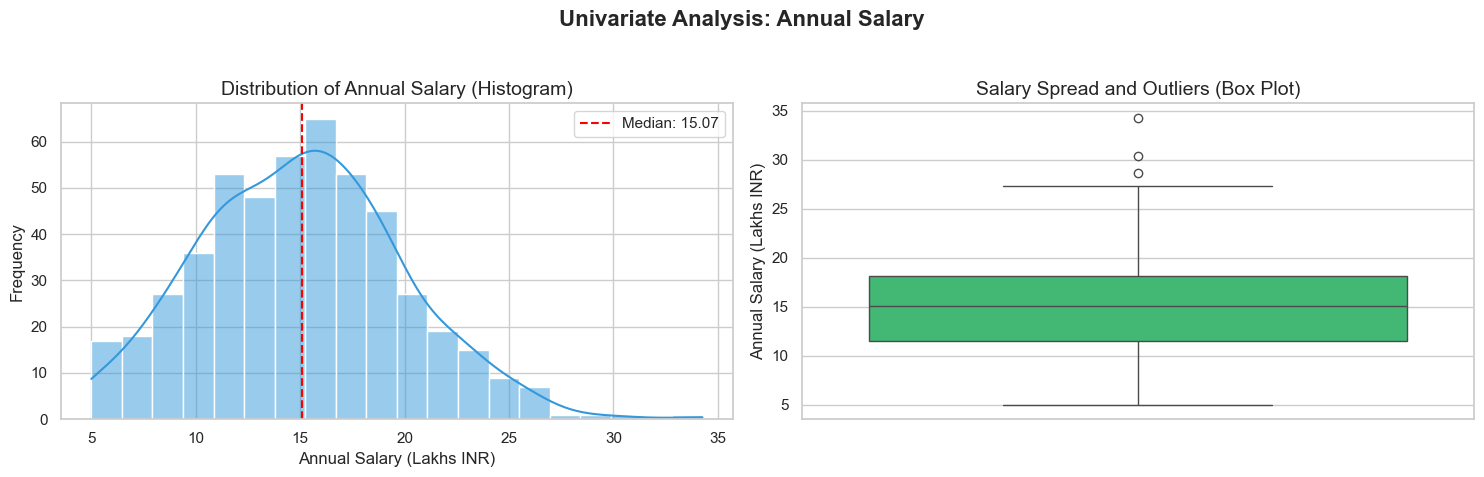

--- 3A. Frequency Counts: Job_Role ---

Value Counts:
Job_Role
Software Engineer    203
Data Scientist       121
Product Manager       71
HR Specialist         55
Technical Writer      50
Name: count, dtype: int64

Proportions (% of Total):
Job_Role
Software Engineer    40.6
Data Scientist       24.2
Product Manager      14.2
HR Specialist        11.0
Technical Writer     10.0
Name: proportion, dtype: float64
--------------------------------------------------



/var/folders/vj/3m_qb0dj5nn9xlsxs1j_knlr0000gn/T/ipykernel_90729/4240689887.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.index, y=job_counts.values, palette='viridis')


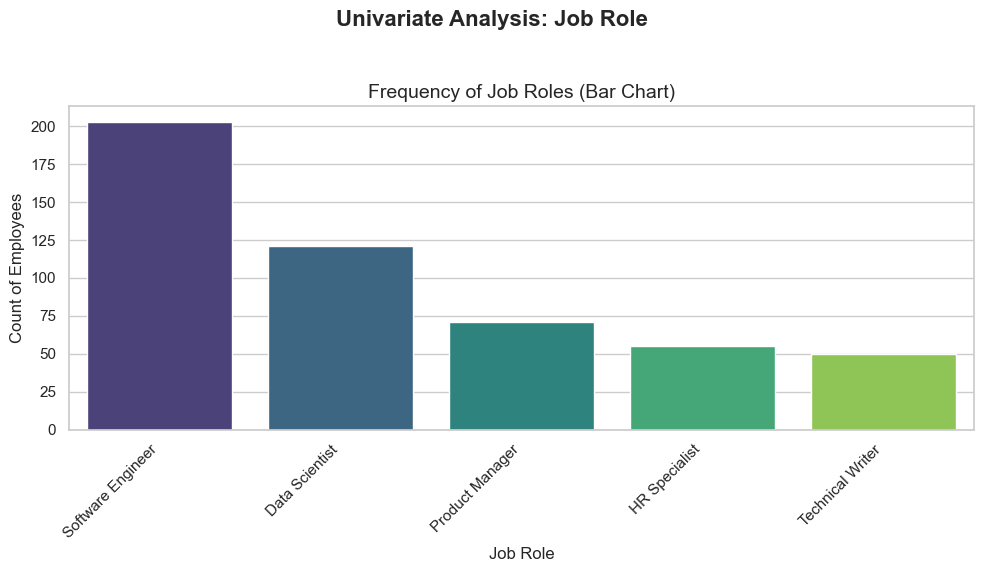


Univariate analysis complete. We now have a solid understanding of each variable individually.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better visualization aesthetics
sns.set_theme(style="whitegrid")

# ======================================================================
# 1. DATA GENERATION (Indian Context)
# ======================================================================

# Create a synthetic dataset
np.random.seed(42) # for reproducibility

data_size = 500

# Annual Salary (in Lakhs INR) - Numerical Variable
salaries = np.random.normal(loc=15, scale=5, size=data_size) # Mean 15 LPA, SD 5
salaries = np.maximum(5, salaries) # Minimum salary of 5 LPA (cleanup)

# Job Role - Categorical Variable
job_roles = np.random.choice(['Software Engineer', 'Data Scientist', 'Product Manager', 'HR Specialist', 'Technical Writer'],
                             size=data_size,
                             p=[0.4, 0.25, 0.15, 0.1, 0.1])

# Education Level - Ordinal Categorical Variable
education_levels = np.random.choice(['B.Tech', 'M.Tech', 'MBA', 'PhD', 'B.Sc/B.A'],
                                   size=data_size,
                                   p=[0.35, 0.30, 0.15, 0.05, 0.15])

# City - Categorical Variable
cities = np.random.choice(['Bangalore', 'Mumbai', 'Delhi-NCR', 'Hyderabad', 'Pune'], size=data_size)


df = pd.DataFrame({
    'Annual_Salary_Lakhs': salaries.round(2),
    'Job_Role': job_roles,
    'Education_Level': education_levels,
    'City': cities
})

print("--- Sample of Generated Data ---")
print(df.head())
print("\n" + "="*50 + "\n")

# ======================================================================
# 2. UNIVARIATE ANALYSIS OF NUMERICAL VARIABLE (Annual Salary)
# ======================================================================
print("--- 2A. Numerical Summary: Annual_Salary_Lakhs (in Lakhs INR) ---")
# Use the .describe() method for quick numerical statistics
salary_stats = df['Annual_Salary_Lakhs'].describe()
print(salary_stats)
print("\n")

print("Interpretation:")
print(f"Mean Salary (Central Tendency): {salary_stats['mean']:.2f} Lakhs")
print(f"Standard Deviation (Spread): {salary_stats['std']:.2f} Lakhs (High spread indicates varied salaries)")
print(f"Min/Max (Range): {salary_stats['min']:.2f} to {salary_stats['max']:.2f} Lakhs")
print("-" * 50 + "\n")


# --- Plots for Numerical Data ---
plt.figure(figsize=(15, 5))

# Histogram (Visualizing Distribution)
plt.subplot(1, 2, 1)
sns.histplot(df['Annual_Salary_Lakhs'], kde=True, bins=20, color='#3498DB')
plt.title('Distribution of Annual Salary (Histogram)', fontsize=14)
plt.xlabel('Annual Salary (Lakhs INR)')
plt.ylabel('Frequency')
plt.axvline(df['Annual_Salary_Lakhs'].median(), color='red', linestyle='--', label=f"Median: {df['Annual_Salary_Lakhs'].median():.2f}")
plt.legend()
# Interpretation: Shows the shape. Is it normal? Is it skewed?

# Box Plot (Visualizing Spread and Outliers)
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Annual_Salary_Lakhs'], color='#2ECC71')
plt.title('Salary Spread and Outliers (Box Plot)', fontsize=14)
plt.ylabel('Annual Salary (Lakhs INR)')
# Interpretation: The dots outside the whiskers are the outliers (the very high/low salaries).

plt.suptitle('Univariate Analysis: Annual Salary', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# ======================================================================
# 3. UNIVARIATE ANALYSIS OF CATEGORICAL VARIABLE (Job Role)
# ======================================================================
print("--- 3A. Frequency Counts: Job_Role ---")
# Use the .value_counts() method to check frequency and proportion
job_counts = df['Job_Role'].value_counts()
job_proportions = df['Job_Role'].value_counts(normalize=True).mul(100).round(2)

print("\nValue Counts:")
print(job_counts)

print("\nProportions (% of Total):")
print(job_proportions)
print("-" * 50 + "\n")


# --- Plot for Categorical Data ---
plt.figure(figsize=(10, 6))

# Bar Chart (Visualizing Frequencies)
sns.barplot(x=job_counts.index, y=job_counts.values, palette='viridis')
plt.title('Frequency of Job Roles (Bar Chart)', fontsize=14)
plt.xlabel('Job Role')
plt.ylabel('Count of Employees')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
# Interpretation: Quickly shows that Software Engineer is the most common role.

plt.suptitle('Univariate Analysis: Job Role', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nUnivariate analysis complete. We now have a solid understanding of each variable individually.")